### Iterative workflow

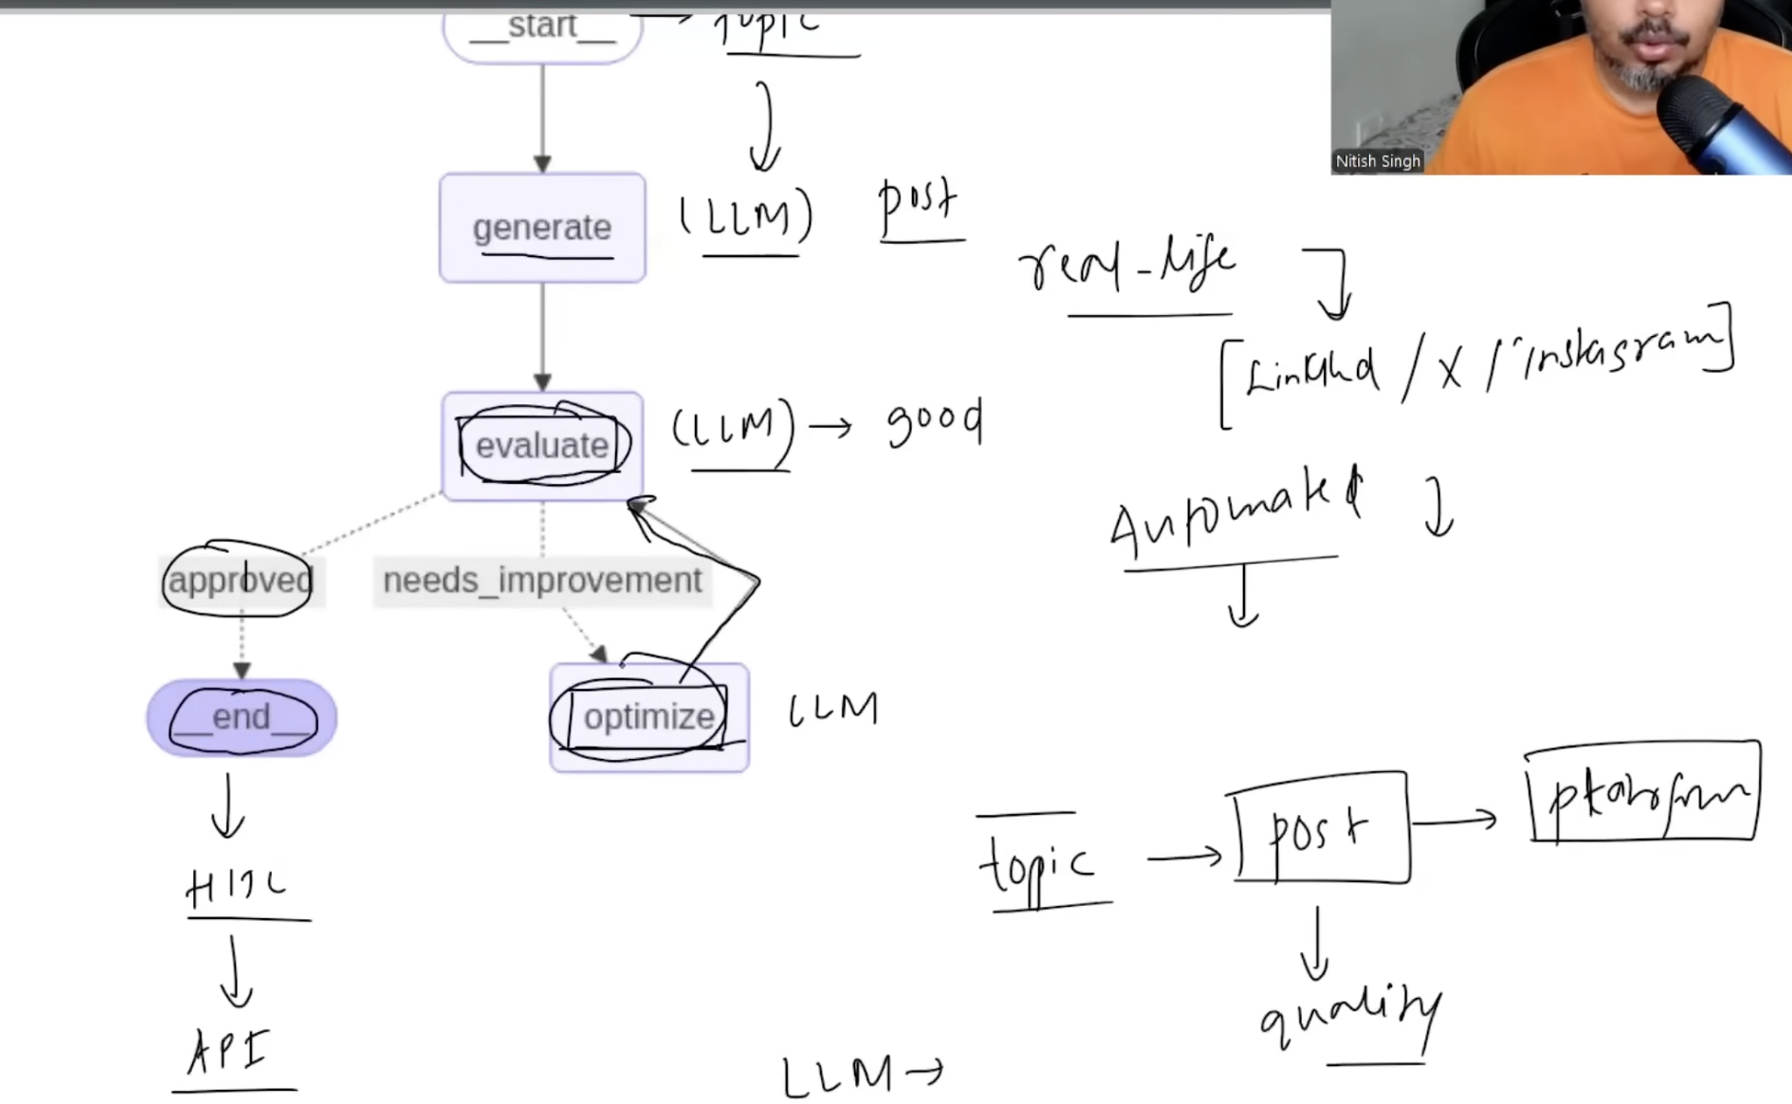

In [23]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated, Literal, Any
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [24]:
generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o')

In [25]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final Evaluation Resultss")
    feedback: str = Field(..., description="feedback for the tweet")

In [26]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [27]:
# state 

class TweetState(TypedDict):
    topic: str      # given by the user
    tweet: str      # tweet that will be generated by the generator LLM
    evaluation: Literal['approved', "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int      # this we will use to close the workflow to avoid the infinite loop

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [28]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [29]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [30]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [31]:
def route_evaluation(state: TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [32]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()


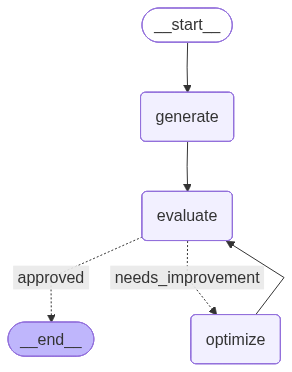

In [33]:
workflow

In [ ]:
initial_state = {
    'topic': 'Indian Railways',
    'iteration': 1,
    "max_iteration" : 5,
}

workflow.invoke(initial_state)

{'topic': 'Indian Railways',
 'tweet': 'Indian Railways: where the snacks are spicy, the seats are a game of musical chairs, and the delays have their own fan clubs. Honestly, if trains ran on time, the chai wallahs would go out of business! ☕🚂 #LifeInIndianRailways #ChaiTime',
 'evaluation': 'approved',
 'feedback': 'This tweet successfully captures the quirks and humor of traveling on Indian Railways, showcasing originality and relatability. The use of vivid imagery regarding spicy snacks and musical chairs for seating adds a playful touch, making it stand out. The humor is light-hearted and will likely resonate with those familiar with the experiences described. It’s also concise and adheres to the tweet format, making it scroll-stopping. The hashtags enhance its potential for virality, encouraging sharing among users who relate to the content.',
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['Indian Railways: where the snacks are spicy, the seats are a game of musical cha

In [37]:
initial_state = {
    'topic': 'cwnjcs',
    'iteration': 1,
    "max_iteration" : 5,
}

result = workflow.invoke(initial_state)

In [38]:
for tweet in result['tweet_history']:
    print(tweet)

Just saw someone say "cwnjcs" is their secret code for bad days. Great! Now I can finally understand the emoji-filled texts from my friends. "💩🍕🤡" means "cwnjcs"? Got it. So how do you say "send coffee" in cwnjcs? ☕️📦
